(exchange_rate_learning)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 汇率不确定性、学习与实验

```{index} single: Bounded Rationality; Exchange Rate Indeterminacy
```

```{contents} Contents
:depth: 2
```

## 概览

在 {doc}`bounded_rationality` 中，我们遇到过一个模型，其中理性预期完全无法确定汇率。

两种法定货币，只要回报率相等就是完美替代品，这使得汇率 $e$ *完全不受限制*：如果均衡条件对某个 $e$ 有解，那么对其他任何 $e$ 也都有解，并且所有情形下的实际配置都是相同的。

本讲座遵循 {cite:t}`Sargent1993` 的思路，将理性主体从这个经济中驱逐出去，代之以适应性主体。

以下内容围绕两个问题展开。

**第一**，学习能否确定汇率？

一个适应性主体拥有信念、修正信念的规则以及初始条件，而这些初始条件恰恰是均衡条件未能确定的东西。

因此，一个由适应性主体组成的系统*可以*在理性预期无法做到的地方选定一个汇率。

我们将看到它确实做到了，但方式非常特殊。

牛顿-拉夫森学习者会收敛到一个**确定的**汇率，而这个汇率完全取决于它们的出发点。

"历史的死手"完成了基本面拒绝完成的锁定任务。

**第二**，不确定性的幽灵是否依然存在？

确实存在。

学习算法的静止点恰好复现了这种不确定性：使算法停止的条件，正是当初使汇率变得自由的那个套利条件。

萨金特将这种使汇率依赖于历史的机制称为确定汇率所依靠的"一根脆弱的芦苇"。

接下来我们转向证据。

{cite:t}`Arifovic1996` 将这一经济体作为付费人类受试者参与的实验室实验来运行。

他们的汇率从未稳定下来。

而当她用**遗传算法**——一个由选择、交叉和变异培育出来的二进制字符串主体群体——替换牛顿-拉夫森学习者时，她得到了一个汇率持续波动的经济体，其频谱与真实的浮动汇率相似。

这种对比——一种收敛的学习规则与一种产生持续波动的学习规则——正是本讲座的落脚点，也是通往 {doc}`marimon_mcgrattan_sargent` 的引桥，在那里遗传算法和分类器系统将完全接管。

让我们先导入一些包。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import NamedTuple

## 双货币经济

我们采用 {cite:t}`KarekenWallace1981` 不确定性的世代交叠模型化身。

在每个时点 $t$，有 $N$ 个生存两期的主体出生，年轻时禀赋为 $w_1$，年老时禀赋为 $w_2$，且 $w_1 > w_2$。

存在两种供给量固定的法定货币 $H_1$ 和 $H_2$。

一个年轻主体做出两项决策：储蓄多少 $s_t$，以及将这部分储蓄中多大比例 $\lambda_t$ 持有为货币 1（其余部分持有货币 2）。

选择 $(s_t, \lambda_t)$ 的主体实现的终身效用为

```{math}
:label: xr_utility

U(s_t, \lambda_t)
= u(w_1 - s_t)
+ u\!\left(w_2 + \lambda_t s_t \frac{p_{1t}}{p_{1,t+1}}
              + (1 - \lambda_t) s_t \frac{p_{2t}}{p_{2,t+1}}\right),
```

其中 $p_{it}$ 是以货币 $i$ 计价的价格水平，$p_{it}/p_{i,t+1}$ 是持有货币 $i$ 的总回报率。

我们全程采用 $u(c) = \ln c$。

将每种货币的供给等同于对它的需求，得到价格水平

```{math}
:label: xr_prices

p_{1t} = \frac{H_1}{\sum_i \lambda_{it} s_{it}},
\qquad
p_{2t} = \frac{H_2}{\sum_i (1 - \lambda_{it}) s_{it}},
```

汇率为 $e_t = p_{1t}/p_{2t}$。

### 回顾不确定性

考虑一个价格恒定的平稳均衡。

那么每种货币的回报为 $p_{it}/p_{i,t+1} = 1$，所以两种回报相等，且 {eq}`xr_utility` 中的组合回报无论 $\lambda$ 为何值都是 $1$。

储蓄决策于是求解 $\max_s \ln(w_1 - s) + \ln(w_2 + s)$，得到

$$
s^\star = \frac{w_1 - w_2}{2},
$$

但组合份额 $\lambda$ 是*完全不确定的*：当两种回报相等时，效用与 $\lambda$ 无关。

而 $\lambda$ 恰恰决定了汇率。

由 {eq}`xr_prices`，在公共的 $(s, \lambda)$ 下，

$$
e = \frac{p_{1}}{p_{2}} = \frac{H_1}{H_2}\cdot\frac{1 - \lambda}{\lambda}.
$$

每一个 $\lambda \in (0, 1)$ 都是均衡，因此每一个 $e \in (0, \infty)$ 都是均衡。

这正是 {doc}`bounded_rationality` 中的不确定性，现在通过一个未确定的组合选择表现了出来。

本讲座将运行两个参数不同的经济体——萨金特的经济体和阿里福维奇的经济体——因此我们将参数放入一个容器中，并显式传递，而不是让它们作为全局变量随意存在。

In [2]:
class Params(NamedTuple):
    w1: float          # 年轻时的禀赋
    w2: float          # 年老时的禀赋
    H1: float          # 货币1的固定供给
    H2: float          # 货币2的固定供给

    @property
    def s_star(self):
        "理性预期储蓄率，当两种货币回报均为1时。"
        return (self.w1 - self.w2) / 2


kw = Params(w1=20.0, w2=15.0, H1=100.0, H2=120.0)

print(f"rational expectations saving rate s* = {kw.s_star}")
print(f"any portfolio share λ is an equilibrium, and e = (H1/H2)(1-λ)/λ is free")

rational expectations saving rate s* = 2.5
any portfolio share λ is an equilibrium, and e = (H1/H2)(1-λ)/λ is free


## 牛顿-拉夫森学习

现在驱逐理性主体。

遵循 {cite:t}`Sargent1993`，我们将总体分成两类——称为"偶数类"和"奇数类"——因为一个世代的终身效用只有等到该世代年老之后才能被评估。

每一类都携带自己的规则 $(s, \lambda)$，仅根据同一类之前主体的经验来更新。

一个主体根据实现的效用，通过**牛顿-拉夫森**步骤来修正 $(s, \lambda)$：朝着根据 {eq}`xr_utility` 的二阶展开、依据主体实际经历的回报本应能提高效用的方向移动。

用 $g$ 表示梯度，$R$ 表示（负定）海森矩阵的滚动估计，递推式为

```{math}
:label: xr_newton

\begin{aligned}
R_{\tau+1} &= R_\tau + \gamma_\tau (H_\tau - R_\tau), \\
\begin{bmatrix} s \\ \lambda \end{bmatrix}_{\tau+1}
&= \begin{bmatrix} s \\ \lambda \end{bmatrix}_\tau
   - \gamma_\tau R_{\tau+1}^{-1}\, g_\tau,
\end{aligned}
```

其中 $H_\tau$ 是实现的海森矩阵，$\gamma_\tau$ 是增益。

下面是 {eq}`xr_utility` 关于回报 $R_1 = p_{1t}/p_{1,t+1}$ 和 $R_2 = p_{2t}/p_{2,t+1}$ 的梯度与海森矩阵。

In [3]:
def grad_hess(p, s, lam, R1, R2):
    "实现效用 U(s, λ) 的梯度与海森矩阵。"
    A = lam*R1 + (1 - lam)*R2               # 组合总回报
    c2 = p.w2 + s*A                         # 老年消费
    dR = R1 - R2
    g = np.array([-1/(p.w1 - s) + A/c2,
                  s*dR/c2])
    H_ss = -1/(p.w1 - s)**2 - A**2/c2**2
    H_ll = -s**2 * dR**2 / c2**2
    H_sl = dR/c2 - s*A*dR/c2**2
    return g, np.array([[H_ss, H_sl], [H_sl, H_ll]])

### 不确定性表现为一个奇异海森矩阵

看看海森矩阵中 $\lambda$ 那一块。

当两种回报相等，$R_1 = R_2$ 时，所有 $\lambda$-偏导数都消失了：梯度分量 $s(R_1 - R_2)/c_2$ 为零，曲率 $-s^2(R_1 - R_2)^2/c_2^2$ 也是零。

在回报相等时，效用**沿 $\lambda$ 方向是平坦的**。

这正是局部所见的不确定性：没有任何力量将 $\lambda$ 推向任何方向，因此一次牛顿步骤——将梯度除以曲率——在 $\lambda$ 方向上是 $0/0$。

为使算法能够真正移动，我们必须保持 $R$ 可逆。

我们通过在 $\lambda$ 方向引入一个小的**先验曲率** $\kappa$ 来做到这一点。

从经济学角度看，这恰恰是 {cite:t}`Sargent1993` 所援引的迟滞性：正是它作为"历史的死手"使一个原本自由的汇率能够安定下来。

In [4]:
def newton_learning(p, s0, lam0, T=400, gain=0.3, κ=0.5):
    """
    带有牛顿-拉夫森学习(s, λ)的双货币世代交叠模型，每一类（偶数/奇数）一条规则。
    κ是不确定λ方向上的先验曲率，用于保持二阶矩矩阵R可逆。
    """
    s = np.array(s0, float)
    lam = np.array(lam0, float)
    R = [np.array([[-1.0, 0.0], [0.0, -κ]]) for _ in range(2)]   # 先验曲率
    p1 = np.empty(T)
    p2 = np.empty(T)
    e = np.empty(T)
    s_hist = np.empty((T, 2))
    lam_hist = np.empty((T, 2))

    for t in range(T):
        j = t % 2                                    # 在t时年轻的一类
        p1[t] = p.H1 / (lam[j]*s[j])
        p2[t] = p.H2 / ((1 - lam[j])*s[j])
        e[t] = p1[t] / p2[t]
        if t >= 1:                                   # 在t-1时年轻的一类现在年老了
            jp = 1 - j
            R1, R2 = p1[t-1]/p1[t], p2[t-1]/p2[t]
            g, H = grad_hess(p, s[jp], lam[jp], R1, R2)
            H[1, 1] -= κ                         # 保留先验的λ曲率
            R[jp] = R[jp] + gain*(H - R[jp])
            step = gain * np.linalg.solve(R[jp], g)
            s[jp] = np.clip(s[jp] - step[0], 0.1, p.w1 - 0.1)
            lam[jp] = np.clip(lam[jp] - step[1], 0.02, 0.98)
        s_hist[t] = s
        lam_hist[t] = lam

    return e, s_hist, lam_hist

### 收敛到一个依赖历史的汇率

运行两个初始条件不同、其余条件完全相同的实验。

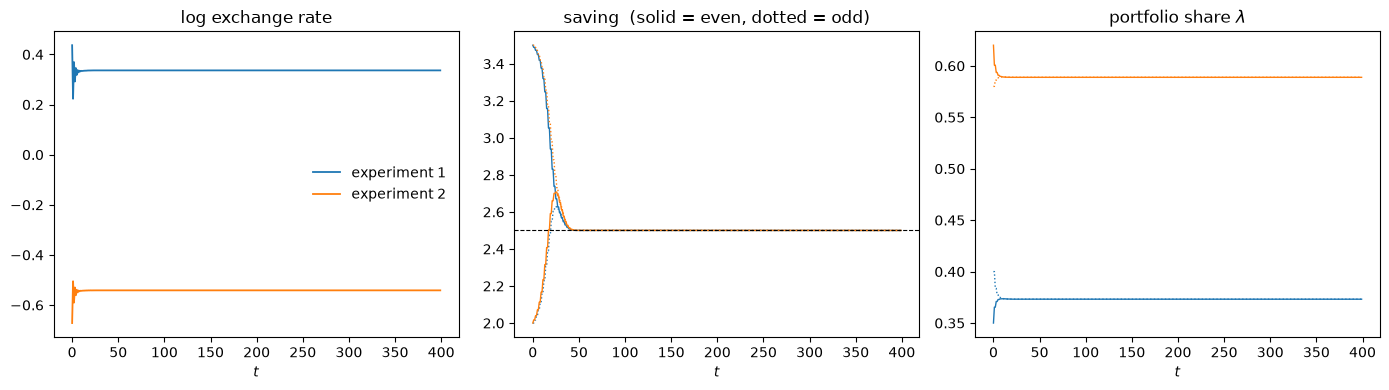

In [5]:
e1, s1, l1 = newton_learning(kw, [3.5, 2.0], [0.35, 0.40])
e2, s2, l2 = newton_learning(kw, [2.0, 3.5], [0.62, 0.58])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(np.log(e1), 'C0', lw=1.3, label="experiment 1")
axes[0].plot(np.log(e2), 'C1', lw=1.3, label="experiment 2")
axes[0].set_title("log exchange rate")
axes[0].set_xlabel("$t$")
axes[0].legend(frameon=False)

for s_h, c in [(s1, 'C0'), (s2, 'C1')]:
    axes[1].plot(s_h[:, 0], color=c, lw=1.0)
    axes[1].plot(s_h[:, 1], color=c, lw=1.0, ls=':')
axes[1].axhline(kw.s_star, color='k', lw=0.8, ls='--')
axes[1].set_title("saving  (solid = even, dotted = odd)")
axes[1].set_xlabel("$t$")

for l_h, c in [(l1, 'C0'), (l2, 'C1')]:
    axes[2].plot(l_h[:, 0], color=c, lw=1.0)
    axes[2].plot(l_h[:, 1], color=c, lw=1.0, ls=':')
axes[2].set_title(r"portfolio share $\lambda$")
axes[2].set_xlabel("$t$")
plt.tight_layout()
plt.show()

两个经济体都收敛了。

储蓄从任一方向都会攀升或下降至理性预期比率 $s^\star = 2.5$，且两类主体的组合份额都汇合到一个共同的值。

但这两个实验收敛到了*不同的汇率*。

它们之间唯一的差别在于组合的起始点。

In [6]:
for name, e, l in [("experiment 1", e1, l1), ("experiment 2", e2, l2)]:
    print(f"{name}: e → {e[-1]:.4f},  s → {s1[-1][0]:.3f},  λ → {l[-1][0]:.3f}")

experiment 1: e → 1.3998,  s → 2.500,  λ → 0.373
experiment 2: e → 0.5819,  s → 2.500,  λ → 0.589


储蓄率是由基本面锁定的；汇率则是由历史锁定的。

### 历史的死手

为了看清历史对结果的支配有多彻底，我们扫描初始组合份额，记录每个经济体最终稳定在哪个汇率上。

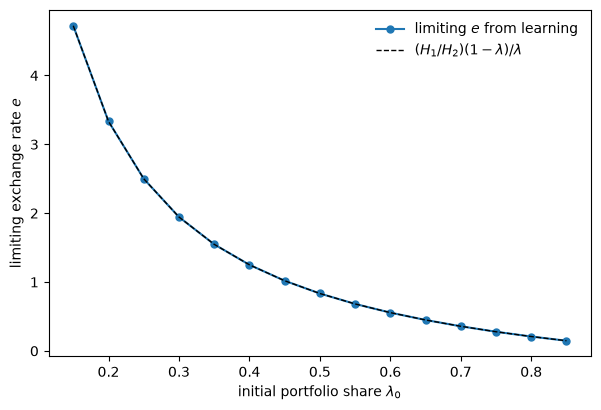

In [7]:
λ0_grid = np.linspace(0.15, 0.85, 15)
e_limits = [newton_learning(kw, [4.0, 4.0], [λ0, λ0])[0][-1] for λ0 in λ0_grid]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(λ0_grid, e_limits, 'C0o-', ms=5, label="limiting $e$ from learning")
ax.plot(λ0_grid, (kw.H1/kw.H2)*(1 - λ0_grid)/λ0_grid, 'k--', lw=1,
        label=r"$(H_1/H_2)(1-\lambda)/\lambda$")
ax.set_xlabel(r"initial portfolio share $\lambda_0$")
ax.set_ylabel("limiting exchange rate $e$")
ax.legend(frameon=False)
plt.show()

极限汇率描绘出了*整个理性预期连续统*。

曲线上的每一点都是有效的理性预期均衡；学习纯粹依据初始条件在其中作出选择。

正是在这个意义上，学习使汇率变得确定。

它并没有添加基本面所缺失的某个基本因素。

它把*水平上的不确定性*转化为*对历史的依赖*：经济体最终到达的汇率，就是初始组合信念所蕴含的那个值，被冻结在原地。

### 不确定性的幽灵

为什么汇率会被冻结，而不是移动到某个特定的值？

因为算法在梯度消失的任何地方都会静止下来，而组合梯度 $s(R_1 - R_2)/c_2$ 恰好在 $R_1 = R_2$ 时消失，而这正是使汇率在理性预期下变得自由的那个**套利条件**。

In [8]:
# at the limit the classes have merged, so prices are constant and R1 = R2 = 1
s_lim, lam_lim = s1[-1], l1[-1]
p1_lim = kw.H1 / (lam_lim*s_lim)
p2_lim = kw.H2 / ((1 - lam_lim)*s_lim)
print(f"classes converged to a common rule:  s = {s_lim.round(4)},  λ = {lam_lim.round(4)}")
print(f"→ prices constant across periods, so R1 = R2 = 1 (arbitrage holds at the rest point)")
print(f"→ the λ-gradient is zero for *any* λ, so learning cannot move the exchange rate off "
      f"wherever history left it")

classes converged to a common rule:  s = [2.5 2.5],  λ = [0.3732 0.3732]
→ prices constant across periods, so R1 = R2 = 1 (arbitrage holds at the rest point)
→ the λ-gradient is zero for *any* λ, so learning cannot move the exchange rate off wherever history left it


学习动态的静止点*就是*理性预期均衡本身，汇率也不例外。

不确定性并没有被消除；它被转移到了初始条件之中。

萨金特对这种机制能够承受多大分量说得很直白：

> 换句话说，一个使汇率依赖于历史的机制，似乎是一种形式欠佳的机制。

一个仅由初始信念的偶然性所决定的汇率，是一根脆弱的芦苇。

如果经济体稍有不同——如果学习规则始终在不断试探而不是安定下来——整个构造都可能崩溃。

而这正是接下来两个例证所展示的内容。

## 来自实验室的证据

{cite:t}`Arifovic1996` 用 $w_1 = 11$、$w_2 = 1$、$H_1 = H_2 = 10$ 将这个双货币经济作为一项付费人类受试者实验来实施。

每个年轻的受试者选择一个储蓄率，以及在两种货币之间分配的比例；实验者根据这些选择清算两个货币市场，正如 {eq}`xr_prices` 所描述的那样。

结果与牛顿-拉夫森模拟完全不同。

汇率持续波动，大致在 $0.5$ 到 $2$ 之间的区间内，没有任何安定下来的迹象。

如果说有什么变化的话，波动幅度在各场次实验中反而增大了。

始终收敛到一个常数值的简单牛顿-拉夫森模型，在这方面表现很差。

因此，阿里福维奇为同一个经济体建立了一个不同的模型，其中主体是由遗传算法培育出来的一个**群体**。

## 遗传算法经济体

现在每一类都是 $N = 30$ 个主体组成的群体，每个主体是长度为 $30$ 的**二进制字符串**：前 $20$ 位编码其储蓄率，后 $10$ 位编码其组合份额。

每一期，年轻群体的字符串被解码为 $(s_i, \lambda_i)$ 对，两个货币市场根据 {eq}`xr_prices` 依总量出清，然后读出汇率。

一代之后，当该世代年老时，每个字符串实现的效用 {eq}`xr_utility` 就是其**适应度**，遗传算法据此培育下一代。

In [9]:
N, L_s, L_lam = 30, 20, 10           # 群体规模；储蓄和组合份额的位数

arifovic = Params(w1=11.0, w2=1.0, H1=10.0, H2=10.0)

def decode(p, pop):
    "二进制字符串 → (s, λ)，其中s在(0, w1)中，λ在(0, 1)中。"
    ints_s = pop[:, :L_s] @ (1 << np.arange(L_s)[::-1])
    ints_l = pop[:, L_s:] @ (1 << np.arange(L_lam)[::-1])
    s = 0.05 + (p.w1 - 0.10) * ints_s / (2**L_s - 1)
    lam = 0.02 + 0.96 * ints_l / (2**L_lam - 1)
    return s, lam

def market_prices(p, pop):
    s, lam = decode(p, pop)
    return p.H1 / np.sum(lam*s), p.H2 / np.sum((1 - lam)*s)

def fitness(p, pop, R1, R2):
    "给定每个字符串所经历的回报，计算其实现的终身效用。"
    s, lam = decode(p, pop)
    c2 = p.w2 + s*(lam*R1 + (1 - lam)*R2)
    return np.log(p.w1 - s) + np.log(np.maximum(c2, 1e-9))

这个遗传算法拥有经典的三种算子——按适应度比例进行父代**选择**、单点**交叉**和位翻转**变异**——再加上阿里福维奇引入的一种算子，即**选举算子**：只有当一个子代在最近一期的回报下会比其父代更优时，它才被纳入下一代，否则父代得以存续。

In [10]:
def genetic_step(p, pop, R1, R2, rng, p_mut=0.033, election=True):
    "从当前一代培育出新的一代。"
    fit = fitness(p, pop, R1, R2)
    weight = fit - fit.min() + 1e-6                  # 平移为正值以用于轮盘赌选择
    new = np.empty_like(pop)
    for k in range(0, N, 2):
        i, j = np.searchsorted(np.cumsum(weight), rng.random(2) * weight.sum())
        parents = np.array([pop[i], pop[j]])
        cut = rng.integers(1, L_s + L_lam)           # 单点交叉
        kids = parents.copy()
        kids[0, cut:], kids[1, cut:] = parents[1, cut:], parents[0, cut:]
        for c in kids:                               # 变异
            c[rng.random(L_s + L_lam) < p_mut] ^= 1
        if election:                                 # 阿里福维奇的选举算子
            f_kids = fitness(p, kids, R1, R2)
            f_par = fitness(p, parents, R1, R2)
            for m in range(2):
                new[k + m] = kids[m] if f_kids[m] > f_par[m] else parents[m]
        else:
            new[k], new[k + 1] = kids
    return new


def genetic_economy(p, T=3000, seed=0, election=True):
    rng = np.random.default_rng(seed)
    pops = [rng.integers(0, 2, (N, L_s + L_lam)) for _ in range(2)]   # 偶数、奇数
    p1 = np.empty(T)
    p2 = np.empty(T)
    e = np.empty(T)
    for t in range(T):
        j = t % 2
        p1[t], p2[t] = market_prices(p, pops[j])
        e[t] = p1[t] / p2[t]
        if t >= 1:
            jp = 1 - j
            R1, R2 = p1[t-1]/p1[t], p2[t-1]/p2[t]
            pops[jp] = genetic_step(p, pops[jp], R1, R2, rng, election=election)
    return e

### 永不消退的波动

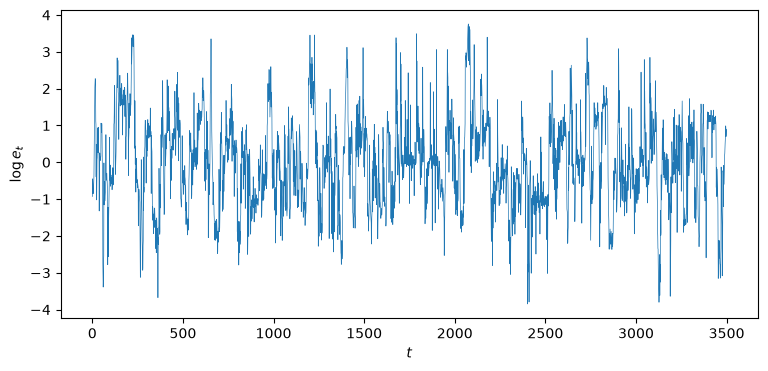

In [11]:
e_ga = genetic_economy(arifovic, T=4000, seed=1)
log_e = np.log(e_ga[500:])                            # 舍弃一段预烧期

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(log_e, lw=0.5)
ax.set_xlabel("$t$")
ax.set_ylabel("$\\log e_t$")
plt.show()

汇率不断波动，而且持续波动下去。

与牛顿-拉夫森学习者不同，这个遗传群体从未安定下来：变异不断注入新的字符串，市场也不断对其重新定价。

这种波动是一种永久性特征，而不是一种暂态现象。

In [12]:
early = np.log(e_ga[500:1500]).std()
late = np.log(e_ga[3000:]).std()
print(f"standard deviation of log e, early window: {early:.3f}")
print(f"standard deviation of log e, late window:  {late:.3f}")
print("→ the volatility does not damp out over time")

standard deviation of log e, early window: 1.279
standard deviation of log e, late window:  1.194
→ the volatility does not damp out over time


### 波动的形态

阿里福维奇报告称，她的遗传经济体中的汇率行为几乎就像随机游走——但带有**均值回复**性质，表现为其一阶差分频谱在零频率处出现一个凹陷。

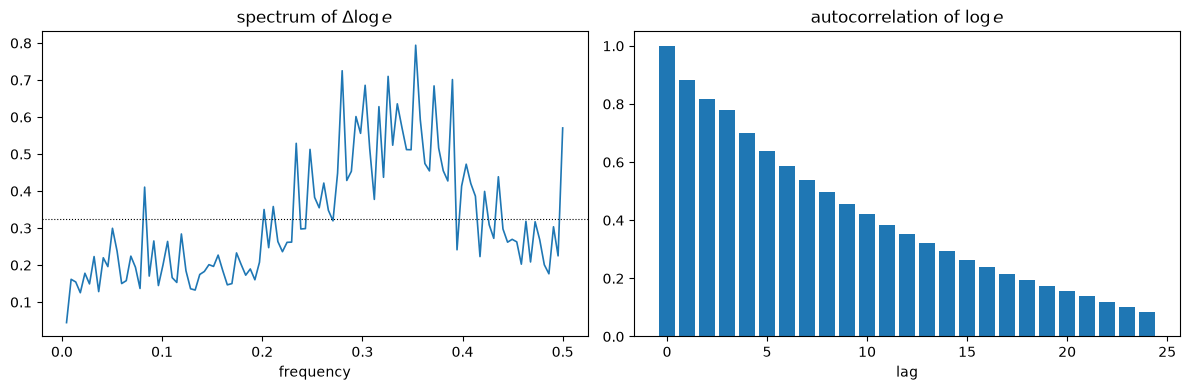

In [13]:
def averaged_spectrum(x, n_seg=16):
    "巴特利特平均周期图，用于获得可读的频谱估计。"
    x = x - x.mean()
    seg = len(x) // n_seg
    acc = np.zeros(seg // 2 + 1)
    for k in range(n_seg):
        acc += np.abs(np.fft.rfft(x[k*seg:(k+1)*seg]))**2 / seg
    return np.fft.rfftfreq(seg), acc / n_seg


d_log_e = np.diff(np.log(e_ga[500:]))
d_log_e = np.clip(d_log_e, *np.percentile(d_log_e, [1, 99]))    # 缩尾处理极端值
freq, spec = averaged_spectrum(d_log_e)

def acf(x, K):
    x = x - x.mean()
    return np.array([np.sum(x[k:]*x[:len(x)-k]) / np.sum(x*x) for k in range(K)])


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(freq[1:], spec[1:], lw=1.2)
axes[0].axhline(spec[1:].mean(), color='k', ls=':', lw=0.8)
axes[0].set_title(r"spectrum of $\Delta \log e$")
axes[0].set_xlabel("frequency")

axes[1].bar(range(25), acf(np.log(e_ga[500:]), 25))
axes[1].set_title(r"autocorrelation of $\log e$")
axes[1].set_xlabel("lag")
plt.tight_layout()
plt.show()

一阶差分的频谱在零频率附近较低，并向更高频率上升，这是一个*水平*值接近随机游走的序列的特征，但又具有足够的均值回复性，将低频功率压低下去。

水平值的自相关衰减缓慢，如同近单位根序列那样，但它*确实*会衰减，而纯粹的随机游走则不会如此。

In [14]:
band = slice(1, len(spec)//2)
print(f"spectral power of Δlog e near zero frequency: {spec[1]:.4f}")
print(f"average spectral power over low-to-mid band:  {spec[band].mean():.4f}")
print(f"→ pronounced dip at zero frequency (mean reversion): {spec[1] < spec[band].mean()}")

spectral power of Δlog e near zero frequency: 0.0446
average spectral power over low-to-mid band:  0.2174
→ pronounced dip at zero frequency (mean reversion): True


该书的评估是：真实的硬通货货币对浮动汇率的对数差分频谱看起来与此非常相似，只是*没有*零频率处的凹陷；实际汇率更加接近纯粹的随机游走。

阿里福维奇的遗传经济体在完全没有基本面冲击的情况下，仅凭一个不断适应的主体群体对两种本质上完全相同的货币重新定价，就在很大程度上产生了这种效果。

## 结语

对同一个不确定经济体的两个模型给出了两种截然不同的结论。

牛顿-拉夫森学习者会**收敛**——而且正是在收敛的过程中，暴露了这种不确定性，而不是消除了它。

它的静止点是一个使汇率保持自由的套利条件，因此极限汇率就是历史上初始组合信念所蕴含的那个值。

依靠死手来确定，萨金特认为这是一根脆弱的芦苇。

遗传算法经济体则**不会收敛**。

一整个由不断变异刷新、由市场不断重新定价的适应性字符串所组成的群体，产生了永不消退的汇率波动，这种波动模仿了真实浮动汇率的低频行为——而这个经济体根本没有任何基本面扰动。

它们之间的差距并不在于经济学本身，因为经济学是相同的，而在于*适应机制*本身。

一种能够稳定单一主体学习的装置——即只保留改进后代的选举算子——在一个自我指涉的市场内部，结果却维持了波动而不是抑制了波动（见 {ref}`xr_ex2`）。

经济学家采用哪种学习模型，再一次成为有限理性研究纲领被迫摆到台面上来的诸多选择之一。

这套机制——霍兰德的遗传算法及其更为丰富的近亲，分类器系统——正是 {doc}`marimon_mcgrattan_sargent` 的主题，在那里，一个由适应性主体组成的群体不仅要调整组合，还必须*从零开始发现*哪种商品将充当货币。

## 练习

```{exercise-start}
:label: xr_ex1
```

牛顿-拉夫森经济体会收敛到一个静止点，在该点上两类主体共享一条公共规则，且套利条件 $R_1 = R_2$ 成立。

通过让两类主体以**非对称**方式起步，验证极限汇率依赖于*整个*初始条件，而不仅仅是初始 $\lambda$ 这一说法。

从若干个初始条件出发运行学习者，其中偶数类和奇数类以不同的组合份额起步，并确认：(a) 两类主体的份额会汇合到一个共同的值；(b) 储蓄会收敛到 $s^\star$；(c) 极限汇率依赖于起始点。

共同的极限 $\lambda$ 是否等于两个初始份额的平均值？

```{exercise-end}
```

```{solution-start} xr_ex1
:class: dropdown
```

In [15]:
rows = []
starts = [([3.0, 2.2], [0.30, 0.50]),
          ([2.2, 3.0], [0.50, 0.30]),
          ([3.5, 2.0], [0.35, 0.55]),
          ([2.5, 2.5], [0.40, 0.60])]
for s0, lam0 in starts:
    e, s_h, l_h = newton_learning(kw, s0, lam0, T=600)
    rows.append([str(lam0), l_h[-1][0], l_h[-1][1], s_h[-1].mean(),
                 e[-1], np.mean(lam0)])

pd.DataFrame(rows, columns=["initial λ", "λ even (limit)", "λ odd (limit)",
                            "s (limit)", "e (limit)", "mean of initial λ"]).round(4)

,initial λ,λ even (limit),λ odd (limit),s (limit),e (limit),mean of initial λ
0,"[0.3, 0.5]",0.4117,0.4117,2.5,1.1908,0.40
1,"[0.5, 0.3]",0.3666,0.3666,2.5,1.4397,0.40
2,"[0.35, 0.55]",0.4433,0.4433,2.5,1.0463,0.45
3,"[0.4, 0.6]",0.5208,0.5208,2.5,0.7668,0.50


两类主体的份额始终会汇合（第2列和第3列一致），储蓄始终收敛到 $s^\star = 2.5$，且极限汇率在不同起始点之间有所不同——因此它确实依赖于历史。

但共同的极限 $\lambda$ **并不**只是两个初始份额的简单平均：将汇合后的值与最后一列进行比较即可看出。

暂态路径很重要，因为在两类主体仍然存在差异时，回报也存在差异，而这些暂态回报差在套利条件关闭这种运动之前，会推动 $\lambda$ 四处移动。

汇率记录的是整个调整过程的历史，而不仅仅是其起始平均值。

```{solution-end}
```

```{exercise-start}
:label: xr_ex2
```

阿里福维奇的**选举算子**只在一个子代在最新回报下击败其父代时才将其纳入下一代。

在单主体优化中，这样一个过滤器只可能带来好处——它永远不会让一个更差的规则取代一个更好的规则。

但这个经济体是*自我指涉的*：用于衡量适应度的回报本身正是由群体的选择所决定的。

请研究选举算子对汇率波动性的影响。

在若干个种子值下分别运行带有和不带有该算子的遗传经济体，并报告对数汇率的波动性。

该算子将波动性推向哪个方向？你能解释原因吗？

```{exercise-end}
```

```{solution-start} xr_ex2
:class: dropdown
```

In [16]:
rows = []
for election in (True, False):
    sds = [np.log(genetic_economy(arifovic, T=2500, seed=sd,
                                  election=election)[500:]).std()
           for sd in range(6)]
    rows.append([election, np.mean(sds), np.min(sds), np.max(sds)])

pd.DataFrame(rows, columns=["election operator", "mean s.d. of log e",
                            "min", "max"]).round(3)

,election operator,mean s.d. of log e,min,max
0,True,1.220,1.081,1.350
1,False,0.522,0.473,0.553


选举算子会**提高**波动性——这与它在单主体搜索中的稳定作用恰恰相反。

其机制在于自我指涉性。

在开启该过滤器的情况下，群体只保留在*上一期回报下*击败其父代的后代，因此它会追逐最近有利可图的组合。

但"最近有利可图"取决于汇率，而汇率恰恰会被群体自身的追逐所推动——于是整个群体都涌向最近的赢家，出现过度反应，汇率随之剧烈变动，使另一种组合变得有利可图，于是群体又转而追逐那一种组合。

如果关闭该过滤器，变异会使群体保持分散，各种不同的组合在总量层面 {eq}`xr_prices` 上会部分相互抵消，从而抑制了波动。

一种能够毫不含糊地改善孤立学习者的装置，却可能使一个由学习者组成的市场变得不稳定。

这是一个简明的警示：不能将单主体的直觉简单套用到多主体系统之中——这一主题在 {doc}`marimon_mcgrattan_sargent` 中还会再次出现。

```{solution-end}
```

```{exercise-start}
:label: xr_ex3
```

本讲声称遗传经济体的汇率"接近随机游走，但带有均值回复"。

请将这一说法量化。

将 $\log e_t$ 视为数据，估计一阶自回归模型 $\log e_t = \mu + \phi \log e_{t-1} + \varepsilon_t$ 中的系数，并将其与 $1$（纯随机游走）进行比较。

对若干个种子值分别进行此项估计。

$\phi$ 是否接近但小于 $1$，与一个近单位根、具有均值回复性质的序列相符？

```{exercise-end}
```

```{solution-start} xr_ex3
:class: dropdown
```

In [17]:
def ar1_coefficient(x):
    "OLS估计x_t = μ + φ x_{t-1} + ε中的φ。"
    x0, x1 = x[:-1], x[1:]
    X = np.column_stack([np.ones_like(x0), x0])
    μ, φ = np.linalg.lstsq(X, x1, rcond=None)[0]
    return φ

rows = []
for sd in range(6):
    le = np.log(genetic_economy(arifovic, T=3000, seed=sd)[500:])
    rows.append([sd, ar1_coefficient(le)])

table = pd.DataFrame(rows, columns=["seed", "AR(1) coefficient φ"])
print(table.round(4).to_string(index=False))
print(f"\nmean φ across seeds: {table['AR(1) coefficient φ'].mean():.4f}")

 seed  AR(1) coefficient φ
    0               0.9165
    1               0.8849
    2               0.8974
    3               0.8739
    4               0.8726
    5               0.8979

mean φ across seeds: 0.8905


估计出的 $\phi$ 始终接近 $1$，但严格小于 $1$——一个高度持续的序列，但仍会回归其均值，而不是永远漂移下去。

这正是频谱所展示的那种"接近随机游走但带有均值回复"的特征：一个纯粹的随机游走会有精确等于 $1$ 的 $\phi$（且零频率处没有凹陷），而略低于 $1$ 的取值则产生了我们所看到的缓慢自相关衰减和低频凹陷。

遗传经济体在没有任何基本面冲击驱动的情况下，仅凭自身就落入了这个近单位根区域——这种持续性完全是由对两种本质上相同的货币进行重新定价的群体动态所制造出来的。

```{solution-end}
```